# Introduction to Natural Language Processing: Assignment 2

In this exercise we'll practice features extraction using Tf-Idf and SpaCy as well as multiclass text classification using the word embedding technique.

- You can use built-in Python packages, spaCy, scikit-learn, Numpy and Pandas.
- Please comment your code
- Submissions are due Tuesdays at 23:59 **only** on eCampus: **Assignmnets >> Student Submissions >> Assignment 2 (Deadline: 18.11.2025, at 23:59)**

- Name the file aproppriately: "Assignment_2_\<Your_Name\>.ipynb" and submit only the Jupyter Notebook file.
- If you are working in a group of two, please have the names of both of the members in the file name.
- Please use relative path, your code should work on my computer if the Jupyter Notebook and the file are both in the same directory.

Example: file_name = bbc-news.csv, **DON'T use:** /Users/ComputerName/Username/Documents/.../bbc-news.csv

### Task 1 (2 points)

Write a function `extract_proper_nouns(my_file_name)` that takes a file name (my_file_name.txt) as input and returns a list containing all proper nouns with more than one token.

**Example:**

text = "Hong Kong and Japan are two countries in Asia and New York is the largest city in the world"

return = `["New York", "Hong Kong"]` **(Note: it should not return "Japan")**

In [1]:
import spacy

def extract_proper_nouns(my_file_name):

    several_token_propn = []

    # Load spaCy
    nlp = spacy.load("en_core_web_sm")

    # Read the text file
    with open(my_file_name, "r", encoding="utf-8") as f:
        text = f.read()

    # Process text with spaCy
    doc = nlp(text)

    # Temporary list to collect consecutive PROPN tokens
    current_propn = []

    for token in doc:
        # Check if token is a proper noun
        if token.pos_ == "PROPN":
            current_propn.append(token.text)
        else:
            # If the sequence ended, check if length > 1
            if len(current_propn) > 1:
                several_token_propn.append(" ".join(current_propn))
            current_propn = []

    # Catch any remaining sequence at the end of the document
    if len(current_propn) > 1:
        several_token_propn.append(" ".join(current_propn))

    return several_token_propn


In [2]:
# Create a sample text file 
sample_text = """Hong Kong and Japan are two countries in Asia.
New York is a large city. I once visited Rio de Janeiro and Los Angeles."""

# Create a file named "my_test_file.txt"
with open("my_test_file.txt", "w", encoding="utf-8") as f:
    f.write(sample_text)

# Test the function
result = extract_proper_nouns("my_test_file.txt")
print(result)

['Hong Kong', 'New York', 'Rio de Janeiro', 'Los Angeles']


### Task 2 (3 points)

Write a function `common_lemma(my_file_name)` that takes a file name (my_file_name.txt) as input and returns a Python dictionary with lemmas as `key` and the `value` that should contain a list with both verbs and nouns sharing the same lemma.

**Examples:**

1.
text = "When users google for a word or any query, their system internally runs a pipeline in order to process what the person is querying."

return = `{"query": ["query", "querying"]}`

2.
text = I really loved the movie and show, the movie was showing reality but it showed sometimes nonesense!

return = `{"show": ["show", "showing", "showed"]}` **(Note: it should not return "movie" because both "movie"s are NOUN)**

In [3]:
def common_lemma(my_file_name):
    tokens_with_common_lemma = {}

    # Load spaCy English model
    nlp = spacy.load("en_core_web_sm")

    # Read the file
    with open(my_file_name, "r", encoding="utf-8") as f:
        text = f.read()

    # Process the text
    doc = nlp(text)

    # Dictionary to group tokens by lemma
    lemma_dict = {}  # {lemma: {"pos": set(), "forms": set()}}

    for token in doc:
        # Consider only alphabetic tokens
        if not token.text.isalpha():
            continue

        lemma = token.lemma_.lower()
        pos = token.pos_
        form = token.text

        # Track POS and forms per lemma
        if lemma not in lemma_dict:
            lemma_dict[lemma] = {"pos": set(), "forms": set()}

        lemma_dict[lemma]["pos"].add(pos)
        lemma_dict[lemma]["forms"].add(form)

    # Now filter only lemmas that appear as BOTH noun AND verb
    for lemma, data in lemma_dict.items():
        if "NOUN" in data["pos"] and "VERB" in data["pos"]:
            # Convert forms to a sorted list for nicer output
            tokens_with_common_lemma[lemma] = sorted(list(data["forms"]))

    return tokens_with_common_lemma


In [4]:
# Create a sample text file
sample_text = """I really loved the movie and show, 
the movie was showing reality but it showed sometimes nonsense!
People often show kindness, but the show yesterday was amazing."""

# Save it as "my_test_lemma.txt"
with open("my_test_lemma.txt", "w", encoding="utf-8") as f:
    f.write(sample_text)
    
# Test the function
result = common_lemma("my_test_lemma.txt")
print(result)

{'show': ['show', 'showed', 'showing']}


### Task 3 (1 point)

Load the data `bbc-text.csv`; This datata consists of 2225 documents from the BBC news website corresponding to stories from 2004-2005.

In [6]:
# Here comes your code
import pandas as pd
data = pd.read_csv('bbc-news.csv')

### Task 4 (1 point)

Show how many articles we have for each topical area (class label) in the dataset using a plot.

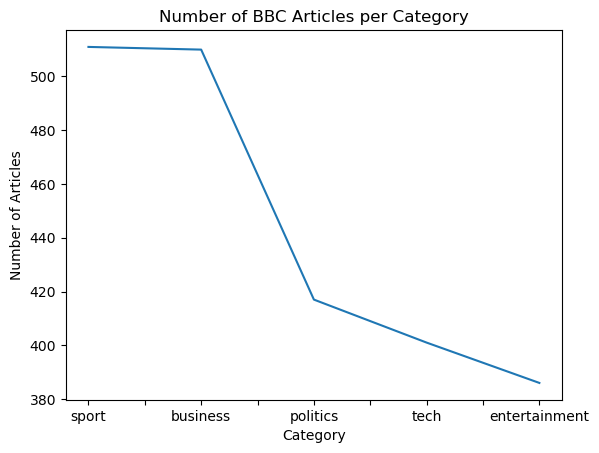

In [8]:
# Here comes your code
import matplotlib.pyplot as plt

# Count number of articles per category
counts = data['category'].value_counts()

# Plot
plt.figure()
counts.plot()
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.title("Number of BBC Articles per Category")
plt.show()

### Task 5 (2 point)

Preprocessing: Define two following functions and apply them to the dataset:
1. Remove punctuation
2. Remove any numbers

In [9]:
import re

def remove_punctuation(corpus):
    cleaned_corpus = []   # <-- You forgot this line

    # Regex to remove all punctuation characters
    pattern = r'[^\w\s]'   # keep letters, numbers, and whitespace only

    for doc in corpus:
        cleaned_text = re.sub(pattern, '', doc)
        cleaned_corpus.append(cleaned_text)

    return cleaned_corpus


def remove_numbers(corpus):
    cleaned_corpus = []

    # Regex to remove digits
    pattern = r'\d+'   # match any number sequence

    for doc in corpus:
        cleaned_text = re.sub(pattern, '', doc)
        cleaned_corpus.append(cleaned_text)

    return cleaned_corpus

In [10]:
texts = data["text"]

# Remove punctuation
texts_no_punct = remove_punctuation(texts)

# Remove numbers
texts_no_numbers = remove_numbers(texts_no_punct)

# Create a new DataFrame with cleaned text
df_clean = pd.DataFrame({
    "category": data["category"],
    "clean_text": texts_no_numbers
})
df_clean.head()

,category,clean_text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


### Task 6.1 (1 points)

Split the data into training and test set (70% and 30%) using scikit-learn, shuffle it, and set the `seed=101 (random_state)`.

**NOTE:** If working with this dataset is not computationaly possible for you, you can work only with a subset of the dataset (i.e., the first 1000 rows) and use only the first 150 tokens for each article. You should point this out in your code.

In [4]:
# Here comes your code
from sklearn.model_selection import train_test_split

seed = 101
X = data['text']
y = data['category']
# split with the percentages given, shuffles it and sets the seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=seed, shuffle=True)

### Task 6.2 (3 points)

### **Training models on TF-IDF vectors:**

a) Convert each article in your data splits to a vector representation using the tf-idf-vectorizer.

b) Using the vectors from the previous step, train the `MLPClassifier` and another model of your choice from the scikit-learn library.

c) Test both of your models on the test set from Task 6.1.

In [15]:
# Here comes your code
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

# converts the articles into the tf-idf representation by learning it from the training set
tfidf = TfidfVectorizer(stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
# transforms the test set into the tf-idf representation using the learned representation
X_test_tfidf = tfidf.transform(X_test)

# defines and trains an MLP and a logistic regression with the tf-idf vector data
mlp_tfidf = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=300, random_state=seed)
mlp_tfidf.fit(X_train_tfidf, y_train)
reg_tfidf = LogisticRegression(max_iter=500)
reg_tfidf.fit(X_train_tfidf, y_train)

# predicts on the test data
y_pred_MLP_tfidf = mlp_tfidf.predict(X_test_tfidf)
y_pred_reg_tfidf = reg_tfidf.predict(X_test_tfidf)

### Task 6.3 (3 points)

### **Training models on SpaCy model vector representation:**

a) Convert each article in your data splits to a vector representation using the pre-trained spaCy model. (**Hint:** It should be stored as an array)

b) Using the vectors from the previous step, train the `MLPClassifier` and another model of your choice from the scikit-learn library.

c) Test both of your models on the test set from Task 6.1.

In [16]:
# Here comes your
import spacy
import spacy.cli
import numpy as np

# uncomment to download the model if it doesnt work
#spacy.cli.download("en_core_web_lg")
# loads a pretrained spacy model to get the vector representation of the text
nlp = spacy.load("en_core_web_lg")

# converts the articles into the spacy vector
X_train_spacy = np.vstack([nlp(text).vector for text in X_train])
X_test_spacy = np.vstack([nlp(text).vector for text in X_test])

# defines the same models as before and trains them on the new data representation
mlp_spacy = MLPClassifier(hidden_layer_sizes=(256, 128, 64), max_iter=300, random_state=seed)
mlp_spacy.fit(X_train_spacy, y_train)
reg_spacy = LogisticRegression(max_iter=500)
reg_spacy.fit(X_train_spacy, y_train)

# predicts on the test data
y_pred_MLP_spacy = mlp_spacy.predict(X_test_spacy)
y_pred_reg_spacy = reg_spacy.predict(X_test_spacy)

### Task 7 (4 points)

Using the predictions from the four classifiers, evaluate the models and report accuracy, recall, precision, f1 scores and confusion matrix for each of them. (**Hint:** You should build a confusion matrix for multi-class classification)

In [17]:
# Here comes your code
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# evaluate the model, printing accuracy, precision, recall, f1 score and the confusion matrix
def evaluate_model(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted"
    )
    cm = confusion_matrix(y_true, y_pred)

    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print("\nConfusion Matrix:")
    print(cm)

# print the results of the models
evaluate_model("MLP (TF-IDF)", y_test, y_pred_MLP_tfidf)
evaluate_model("Logistic Regression (TF-IDF)", y_test, y_pred_reg_tfidf)

evaluate_model("MLP (spaCy vectors)", y_test, y_pred_MLP_spacy)
evaluate_model("Logistic Regression (spaCy vectors)", y_test, y_pred_reg_spacy)


===== MLP (TF-IDF) =====
Accuracy:  0.9850
Precision: 0.9852
Recall:    0.9850
F1 Score:  0.9850

Confusion Matrix:
[[152   0   3   0   0]
 [  0 116   0   0   1]
 [  0   0 121   1   0]
 [  1   0   1 151   0]
 [  0   2   0   1 118]]

===== Logistic Regression (TF-IDF) =====
Accuracy:  0.9746
Precision: 0.9749
Recall:    0.9746
F1 Score:  0.9746

Confusion Matrix:
[[151   0   3   1   0]
 [  2 113   1   0   1]
 [  3   0 119   0   0]
 [  1   0   0 152   0]
 [  3   1   0   1 116]]

===== MLP (spaCy vectors) =====
Accuracy:  0.9701
Precision: 0.9707
Recall:    0.9701
F1 Score:  0.9702

Confusion Matrix:
[[149   0   6   0   0]
 [  0 115   1   0   1]
 [  3   1 118   0   0]
 [  1   0   1 151   0]
 [  2   2   2   0 115]]

===== Logistic Regression (spaCy vectors) =====
Accuracy:  0.9506
Precision: 0.9514
Recall:    0.9506
F1 Score:  0.9507

Confusion Matrix:
[[145   1   8   0   1]
 [  0 112   1   0   4]
 [  4   0 117   0   1]
 [  1   0   1 151   0]
 [  2   4   4   1 110]]
